In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
df = pd.read_csv('D:\\Case Study\\data\\heart_ready.csv')

continuous  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [10]:

def diff_of_means(data, col, label_col='target'):
    means = data.groupby(label_col)[col].mean()
    return abs(means[1] - means[0])

# Null distribution qua permutation — shuffle nhãn
def permutation_test(data, col, n_reps=5000, label_col='target'):
    observed = diff_of_means(data, col, label_col)
    null_dist = []
    for _ in range(n_reps):
        shuffled = data.copy()
        shuffled[label_col] = np.random.permutation(
            data[label_col].values
        )
        null_dist.append(diff_of_means(shuffled, col, label_col))
    null_dist = np.array(null_dist)
    # p-value thực nghiệm = tỷ lệ null >= observed
    p_value = np.mean(null_dist >= observed)
    return observed, null_dist, p_value

In [11]:
print("=" * 62)
print(f"{'Feature':<12} {'Obs. Diff':>10} {'p-value':>10}  Kết luận")
print("=" * 62)

perm_results = {}
for col in continuous:
    obs, null, p = permutation_test(df, col)
    perm_results[col] = {'obs': obs, 'null': null, 'p': p}
    sig = ' Bác bỏ H₀' if p < 0.05 else ' Không bác bỏ H₀'
    print(f"{col:<12} {obs:>10.3f} {p:>10.4f}  {sig}")

Feature       Obs. Diff    p-value  Kết luận
age               4.138     0.0000   Bác bỏ H₀
trestbps          4.943     0.0000   Bác bỏ H₀
chol              9.758     0.0000   Bác bỏ H₀
thalach          19.420     0.0000   Bác bỏ H₀
oldpeak           1.020     0.0000   Bác bỏ H₀


In [12]:

def diff_of_means(data, col, label_col='target'):
    means = data.groupby(label_col)[col].mean()
    return abs(means[1] - means[0])

# Null distribution qua permutation — shuffle nhãn
def permutation_test(data, col, n_reps=5000, label_col='target'):
    observed = diff_of_means(data, col, label_col)
    null_dist = []
    for _ in range(n_reps):
        shuffled = data.copy()
        shuffled[label_col] = np.random.permutation(
            data[label_col].values
        )
        null_dist.append(diff_of_means(shuffled, col, label_col))
    null_dist = np.array(null_dist)
    # p-value thực nghiệm = tỷ lệ null >= observed
    p_value = np.mean(null_dist >= observed)
    return observed, null_dist, p_value

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


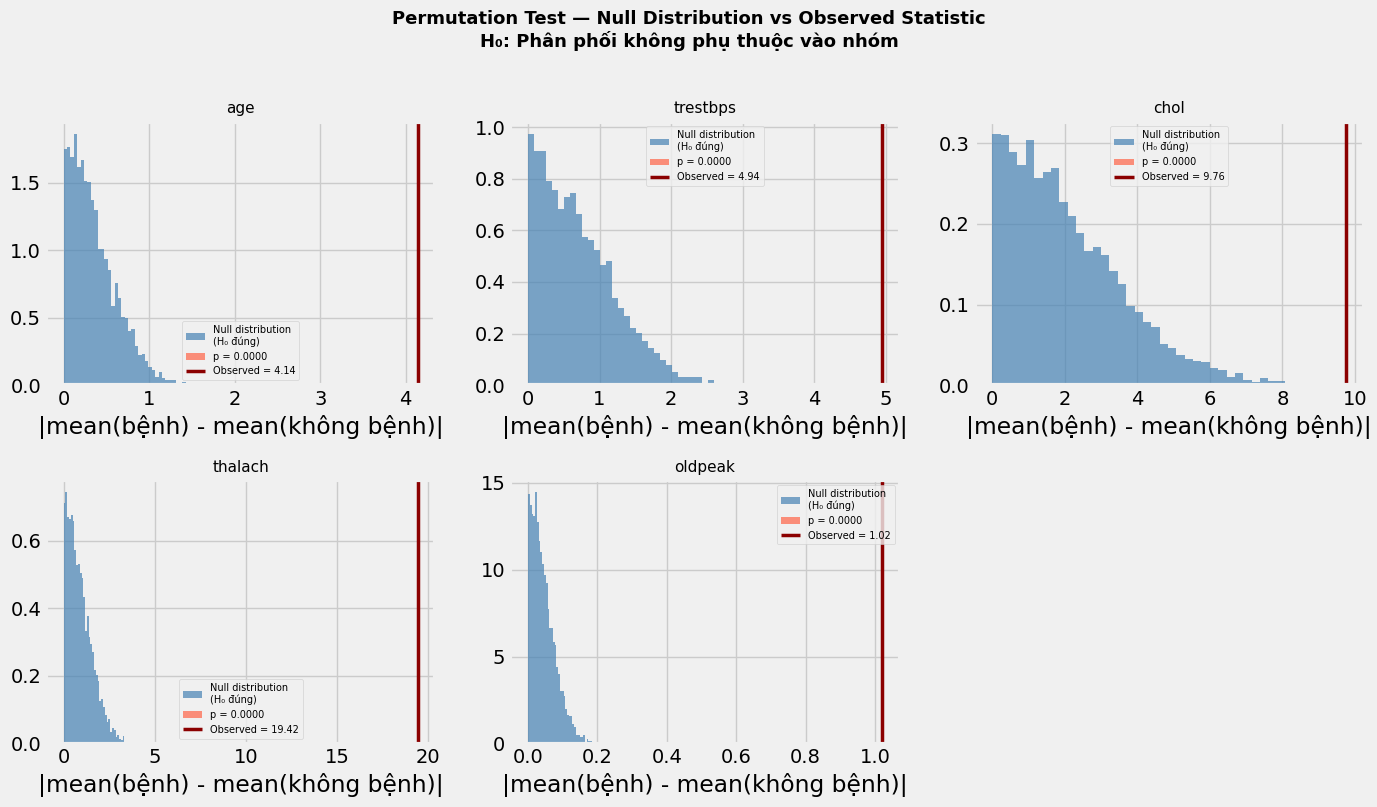

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    obs  = perm_results[col]['obs']
    null = perm_results[col]['null']
    p    = perm_results[col]['p']

    axes[i].hist(null, bins=40, density=True,
                 color='steelblue', alpha=0.7,
                 label='Null distribution\n(H₀ đúng)')

    # Vùng p-value — tô đỏ phần >= observed
    axes[i].hist(null[null >= obs], bins=40, density=True,
                 color='tomato', alpha=0.7,
                 label=f'p = {p:.4f}')

    axes[i].axvline(obs, color='darkred', linewidth=2.5,
                    label=f'Observed = {obs:.2f}')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('|mean(bệnh) - mean(không bệnh)|')
    axes[i].legend(fontsize=7)

axes[5].axis('off')
plt.suptitle('Permutation Test — Null Distribution vs Observed Statistic\n'
             'H₀: Phân phối không phụ thuộc vào nhóm',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
def tvd(data, col, label_col='target'):
    """
    Total Variation Distance — test statistic cho categorical
    TVD = 0.5 * sum|P(X=x|group0) - P(X=x|group1)|
    """
    props = (data.groupby(label_col)[col]
               .value_counts(normalize=True)
               .unstack(fill_value=0))
    return 0.5 * np.abs(props.iloc[0] - props.iloc[1]).sum()

def permutation_test_tvd(data, col, n_reps=5000):
    observed = tvd(data, col)
    null_dist = []
    for _ in range(n_reps):
        shuffled = data.copy()
        shuffled['target'] = np.random.permutation(
            data['target'].values
        )
        null_dist.append(tvd(shuffled, col))
    null_dist = np.array(null_dist)
    p_value   = np.mean(null_dist >= observed)
    return observed, null_dist, p_value

print("=" * 62)
print(f"{'Feature':<12} {'Obs. TVD':>10} {'p-value':>10}  Kết luận")
print("=" * 62)

tvd_results = {}
for col in categorical:
    obs, null, p = permutation_test_tvd(df, col)
    tvd_results[col] = {'obs': obs, 'null': null, 'p': p}
    sig = ' Bác bỏ H₀' if p < 0.05 else ' Không bác bỏ H₀'
    print(f"{col:<12} {obs:>10.3f} {p:>10.4f}  {sig}")

Feature        Obs. TVD    p-value  Kết luận
sex               0.259     0.0000   Bác bỏ H₀
cp                0.519     0.0000   Bác bỏ H₀
fbs               0.026     0.1394   Không bác bỏ H₀
restecg           0.178     0.0000   Bác bỏ H₀
exang             0.413     0.0000   Bác bỏ H₀
slope             0.390     0.0000   Bác bỏ H₀
ca                0.483     0.0000   Bác bỏ H₀
thal              0.522     0.0000   Bác bỏ H₀


In [15]:
cost_map = {'age':0,'sex':0,'cp':10,'trestbps':10,'fbs':15,
            'restecg':30,'chol':20,'thalach':80,'exang':80,
            'oldpeak':80,'slope':80,'ca':300,'thal':400}

rows = []
for col in continuous:
    r = perm_results[col]
    rows.append({'feature':col, 'test':'diff of means',
                 'stat':r['obs'], 'p_value':r['p']})
for col in categorical:
    r = tvd_results[col]
    rows.append({'feature':col, 'test':'TVD',
                 'stat':r['obs'], 'p_value':r['p']})

result_df = pd.DataFrame(rows)
result_df['cost']      = result_df['feature'].map(cost_map)
result_df['sig']       = result_df['p_value'].apply(
    lambda p: '✅' if p < 0.05 else '❌'
)
result_df['keep']      = result_df['p_value'] < 0.05
result_df['stat_norm'] = (
    (result_df['stat'] - result_df['stat'].min()) /
    (result_df['stat'].max() - result_df['stat'].min())
)
result_df['score'] = (
    result_df['stat_norm'] / (result_df['cost'] + 1) * 1000
).round(2)

print("\n" + "=" * 68)
print("XẾP HẠNG FEATURE — Permutation Test")
print("=" * 68)
print(result_df.sort_values('score', ascending=False)
      [['feature','cost','stat','p_value','sig','score']]
      .to_string(index=False))

keep_list = result_df[result_df['keep']]['feature'].tolist()
drop_list = result_df[~result_df['keep']]['feature'].tolist()
print(f"\n Giữ lại ({len(keep_list)}): {keep_list}")
print(f" Loại bỏ ({len(drop_list)}): {drop_list}")

result_df.to_csv('D:\\Case Study\\data\\week3_results.csv', index=False)


XẾP HẠNG FEATURE — Permutation Test
 feature  cost      stat  p_value sig  score
     age     0  4.137888   0.0000   ✅ 212.03
    chol    20  9.757906   0.0000   ✅  23.90
trestbps    10  4.942799   0.0000   ✅  23.05
 thalach    80 19.419720   0.0000   ✅  12.35
     sex     0  0.259340   0.0000   ✅  12.04
      cp    10  0.518613   0.0000   ✅   2.31
 oldpeak    80  1.019968   0.0000   ✅   0.63
 restecg    30  0.177538   0.0000   ✅   0.25
   exang    80  0.412995   0.0000   ✅   0.25
   slope    80  0.390422   0.0000   ✅   0.23
      ca   300  0.482517   0.0000   ✅   0.08
    thal   400  0.521821   0.0000   ✅   0.06
     fbs    15  0.025898   0.1394   ❌   0.00

 Giữ lại (12): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']
 Loại bỏ (1): ['fbs']


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
df = pd.read_csv('D:\\Case Study\\data\\heart_ready.csv')
w3 = pd.read_csv('D:\\Case Study\\data\\week3_results.csv')

# Features pass permutation test
keep_features = w3[w3['keep'] == True]['feature'].tolist()
print(f"Features giữ lại từ Tuần 3: {keep_features}")

Features giữ lại từ Tuần 3: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']
